In [19]:
# ========================
# MODELO PD - IMORA TC
# ========================

# ---- LIBRERIAS -------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, norm
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson as dw_stat


# Configuracion de graficos
plt.style.use('default')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)




In [20]:
# ---- CARGA DE DATOS ---------------------------------------------
# Ruta del archivo (CAMBIAR ESTA RUTA)
ruta = "/content/dataset.xls"

# Cargar el archivo Excel
d1 = pd.read_excel(ruta, sheet_name="dataset")

# Verificar y limpiar nombres de columnas
if 't.objetivo ' in d1.columns:
    d1.rename(columns={'t.objetivo ': 't.objetivo'}, inplace=True)

# Convertir columna Fecha a datetime
d1['Fecha'] = pd.to_datetime(d1['Fecha'])

print(f"\nRango de fechas: {d1['Fecha'].min().strftime('%Y-%m-%d')} a {d1['Fecha'].max().strftime('%Y-%m-%d')}")
print(f"Numero de filas: {len(d1)}")


Rango de fechas: 2007-12-01 a 2025-12-01
Numero de filas: 217


In [21]:
# ============================================================
# 1. DATA FRAME - 27 variables macro
# ============================================================
vars_macro = [
    "CETE28", "t.fija.b5", "t.fija.b10",
    "udib3", "udib10", "PIB",
    "t.desocupacion", "INPC", "TIIE",
    "ahorro.bruto", "IMCP", "IGAE",
    "tipo.de.cambio", "IPC.Var.BMV", "t.objetivo",
    "cartera.consumo.var", "tarjetas.var",
    "rem.comercio.real.var", "remesas.var",
    "infl.subyacente", "consumo.privado.var",
    "m1.var", "m2.var", "balance.publico",
    "tc.utilizadas.var", "cuentas.tc.var",
    "empleo.imss.var"
]

# Crear DataFrame d2
d2 = pd.DataFrame()
d2['Fecha'] = d1['Fecha']
d2['PD'] = d1['IMORA.TC']

# Agregar variables macro
for v in vars_macro:
    d2[v] = pd.to_numeric(d1[v], errors='coerce')

print(f"Dimensiones de d2: {d2.shape}")
print(f"NAs iniciales: {d2.isna().sum().sum()}")

Dimensiones de d2: (217, 29)
NAs iniciales: 16


In [22]:
# ============================================================
# 2. IMPUTACION CON PROMEDIO MOVIL
# ============================================================
def imputar_promedio_movil(x, k=3):
    """Imputa valores faltantes usando promedio movil + interpolacion"""
    if x.isna().all():
        return x

    x_imputed = x.copy()
    actual_k = min(k, len(x_imputed) - 1) if len(x_imputed) > 1 else 1

    # Promedio movil centrado
    x_imputed = x_imputed.rolling(window=actual_k, center=True, min_periods=1).mean()

    # Interpolacion lineal
    x_imputed = x_imputed.interpolate(method='linear', limit_direction='both')

    # Forward fill y backward fill
    x_imputed = x_imputed.fillna(method='ffill').fillna(method='bfill')

    return x_imputed

for v in vars_macro:
    d2[v] = imputar_promedio_movil(d2[v])

print(f"NAs despues de imputacion: {d2.isna().sum().sum()}")

# ============================================================
# 3. VARIABLE DEPENDIENTE: SCORE (logit de la PD)
# ============================================================
d2['PD'] = d2['PD'].clip(lower=1e-6, upper=1-1e-6)
d2['Score'] = np.log(d2['PD'] / (1 - d2['PD']))

print(f"Rango de Score: {d2['Score'].min():.4f} a {d2['Score'].max():.4f}")

NAs despues de imputacion: 0
Rango de Score: -2.9402 a -1.4795


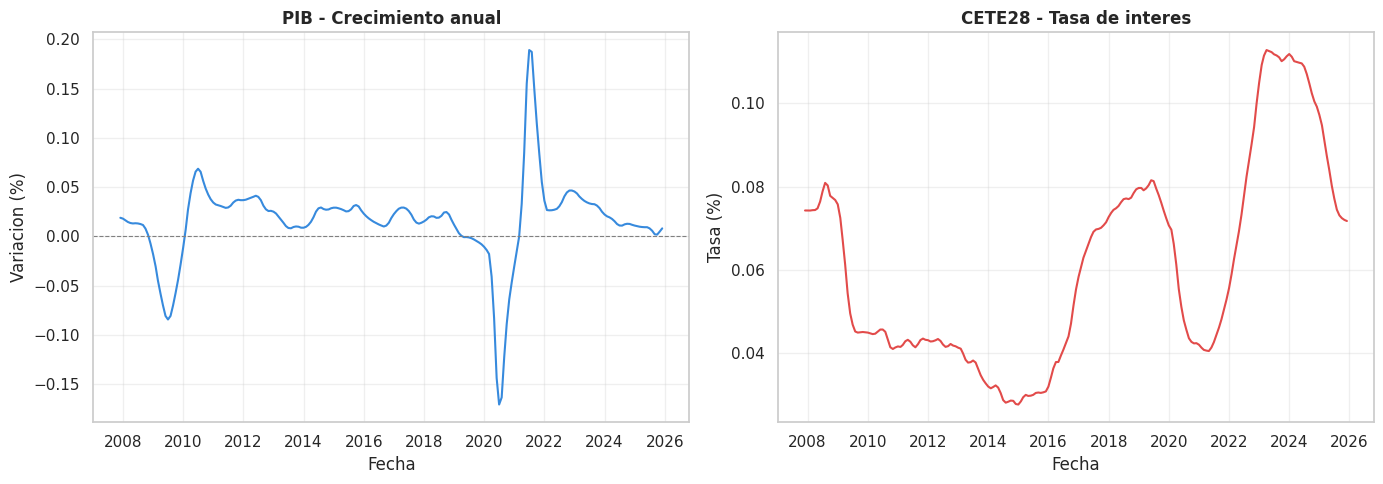

In [23]:
# ============================================================
# 4. ANALISIS UNIVARIADO (graficos basicos)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(d2['Fecha'], d2['PIB'], color='#378ADD', linewidth=1.5)
axes[0].set_title('PIB - Crecimiento anual', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Variacion (%)')
axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(d2['Fecha'], d2['CETE28'], color='#E24B4A', linewidth=1.5)
axes[1].set_title('CETE28 - Tasa de interes', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Tasa (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Observaciones para correlacion: 217


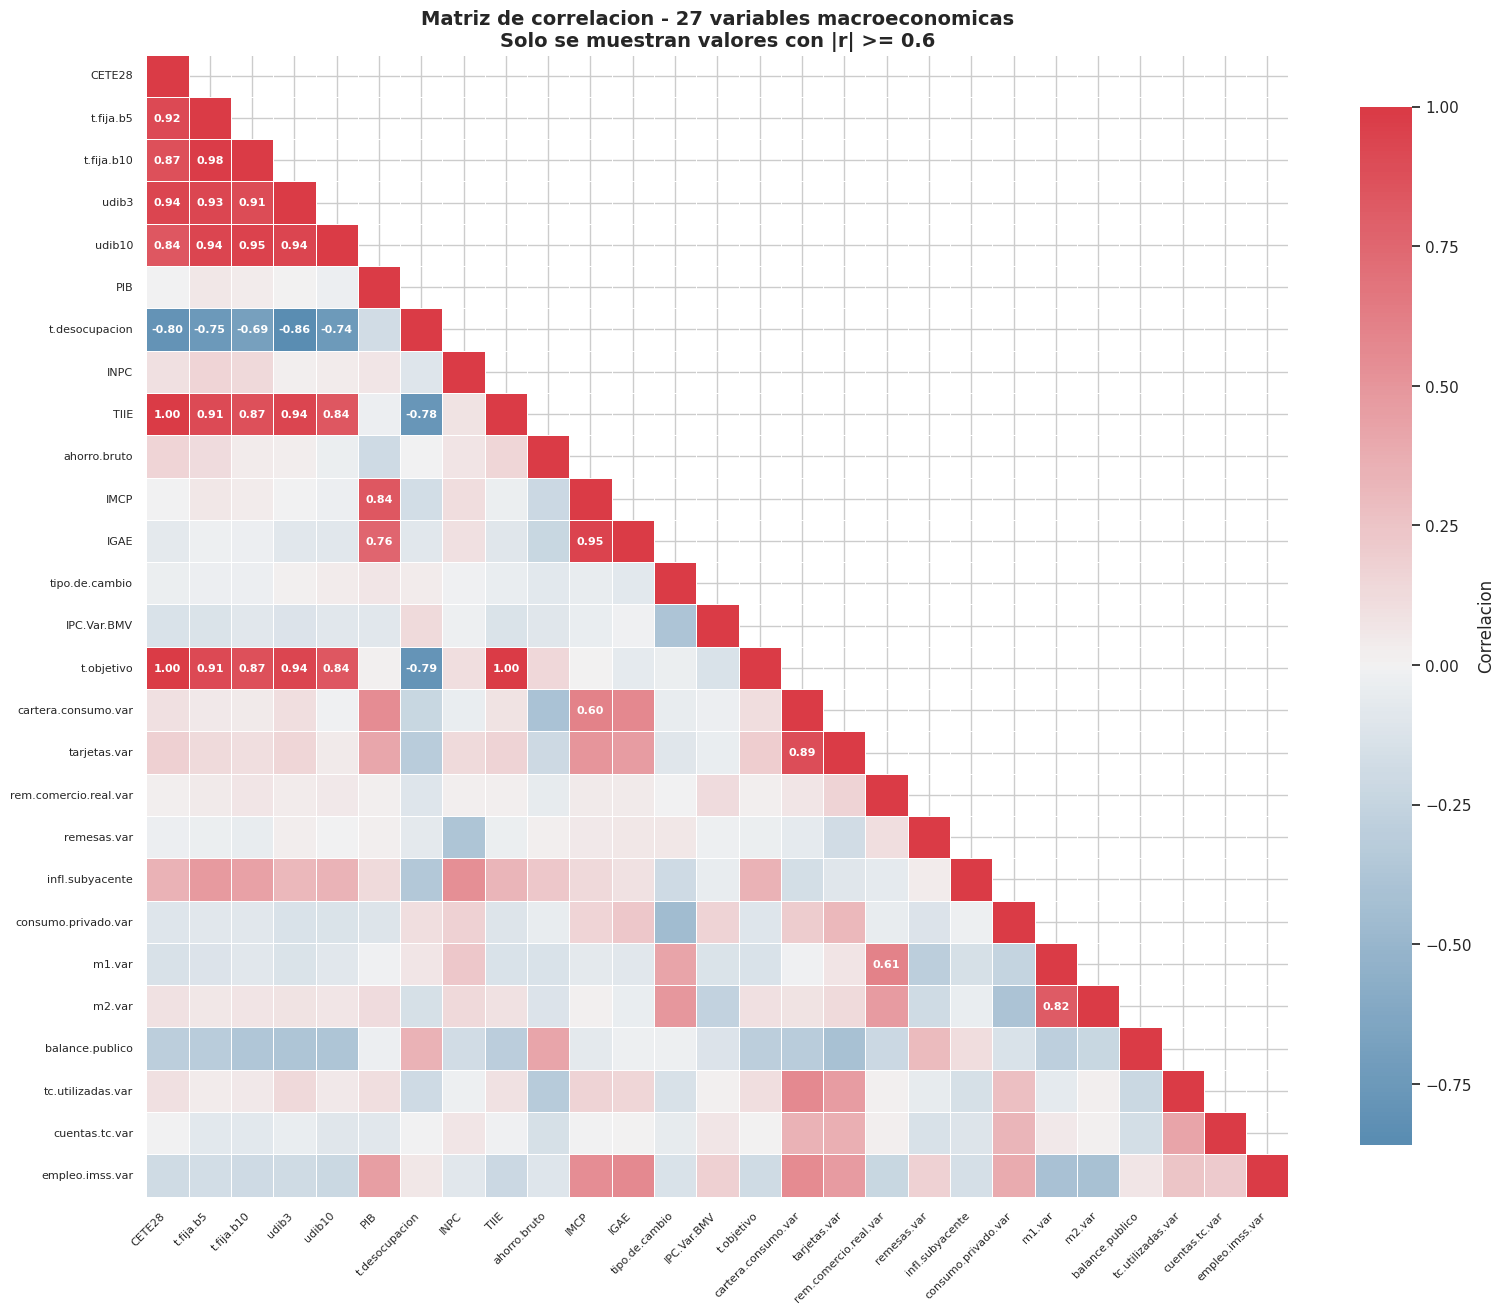

In [24]:
# ============================================================
# 5. MATRIZ DE CORRELACION
# ============================================================
d2_clean_full = d2.dropna(subset=vars_macro)
print(f"\nObservaciones para correlacion: {len(d2_clean_full)}")

mat_cor = d2_clean_full[vars_macro].corr()

# Heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(mat_cor, dtype=bool), k=1)
cmap = sns.diverging_palette(240, 10, n=9, as_cmap=True)

heatmap = sns.heatmap(
    mat_cor, mask=mask, cmap=cmap, center=0, annot=False,
    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8, "label": "Correlacion"}
)

# Agregar anotaciones para |r| >= 0.6
for i in range(len(mat_cor.columns)):
    for j in range(len(mat_cor.index)):
        if j <= i:
            corr_val = mat_cor.iloc[i, j]
            if abs(corr_val) >= 0.6 and i != j:
                heatmap.text(j + 0.5, i + 0.5, f'{corr_val:.2f}',
                           ha='center', va='center', fontsize=8, color='white', fontweight='bold')

plt.title('Matriz de correlacion - 27 variables macroeconomicas\nSolo se muestran valores con |r| >= 0.6',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# 6. VENTANAS DE TIEMPO
# ============================================================
ventanas = {
    'completa': ('2007-12-01', '2025-12-01'),
    'desde_2008': ('2008-01-01', '2025-12-01'),
    'desde_2009': ('2009-01-01', '2025-12-01'),
    'desde_2013': ('2013-01-01', '2025-12-01'),
    'desde_2018': ('2018-01-01', '2025-12-01')
}

def filtrar_ventana(datos, inicio, fin):
    return datos[(datos['Fecha'] >= pd.to_datetime(inicio)) &
                 (datos['Fecha'] <= pd.to_datetime(fin))]

datasets_ventana = {}
for nombre, (inicio, fin) in ventanas.items():
    df_filtrado = filtrar_ventana(d2_clean_full, inicio, fin)
    datasets_ventana[nombre] = df_filtrado
    print(f"Ventana {inicio} a {fin}: {len(df_filtrado)} observaciones")


Ventana 2007-12-01 a 2025-12-01: 217 observaciones
Ventana 2008-01-01 a 2025-12-01: 216 observaciones
Ventana 2009-01-01 a 2025-12-01: 204 observaciones
Ventana 2013-01-01 a 2025-12-01: 156 observaciones
Ventana 2018-01-01 a 2025-12-01: 96 observaciones


In [26]:
# ============================================================
# 7. ESTANDARIZACION
# ============================================================
def estandarizar(datos):
    datos_std = datos.copy()
    for v in vars_macro:
        mean_val = datos_std[v].mean()
        std_val = datos_std[v].std()
        if std_val > 0:
            datos_std[v] = (datos_std[v] - mean_val) / std_val
    return datos_std

datasets_std = {}
for nombre, df in datasets_ventana.items():
    datasets_std[nombre] = estandarizar(df)

print("Datasets estandarizados")

Datasets estandarizados


In [27]:
# ============================================================
# 8. MODELOS COMPLETOS (27 variables)
# ============================================================
def ajustar_modelo(datos, vars_predictoras, nombre_modelo=""):
    if datos is None or len(datos) == 0:
        return None

    X = datos[vars_predictoras].copy()
    X = sm.add_constant(X)
    y = datos['Score']

    mask = ~(X.isna().any(axis=1) | y.isna())
    X = X[mask]
    y = y[mask]

    if len(X) == 0:
        return None

    return sm.OLS(y, X).fit()

print("\n" + "="*60)
print("MODELOS COMPLETOS (27 VARIABLES)")
print("="*60)

mod1 = ajustar_modelo(datasets_std.get('desde_2008'), vars_macro, "MOD1")
mod2 = ajustar_modelo(datasets_std.get('desde_2009'), vars_macro, "MOD2")
mod3 = ajustar_modelo(datasets_std.get('desde_2013'), vars_macro, "MOD3")
mod4 = ajustar_modelo(datasets_std.get('desde_2018'), vars_macro, "MOD4")

for i, mod in enumerate([mod1, mod2, mod3, mod4], 1):
    if mod:
        print(f"\nMOD{i}: R2 adj = {mod.rsquared_adj:.4f}, AIC = {mod.aic:.2f}, vars = {len(mod.params)-1}")



MODELOS COMPLETOS (27 VARIABLES)

MOD1: R2 adj = 0.6328, AIC = -69.02, vars = 27

MOD2: R2 adj = 0.7092, AIC = -131.01, vars = 27

MOD3: R2 adj = 0.9062, AIC = -396.12, vars = 27

MOD4: R2 adj = 0.9363, AIC = -242.67, vars = 27


In [28]:
# ============================================================
# 9. MODELOS REDUCIDOS (especificacion manual)
# ============================================================
vars_red_2008 = [
    't.fija.b5', 't.desocupacion', 'ahorro.bruto', 'tipo.de.cambio',
    'balance.publico', 'cartera.consumo.var', 'remesas.var', 'm2.var',
    'empleo.imss.var', 'tc.utilizadas.var'
]

vars_red_2013 = [
    't.fija.b5', 'udib10', 'TIIE', 'ahorro.bruto', 'tipo.de.cambio',
    'cartera.consumo.var', 'empleo.imss.var', 'balance.publico', 'tc.utilizadas.var'
]

vars_red_2018 = [
    't.fija.b5', 'udib10', 'TIIE', 'ahorro.bruto', 'tipo.de.cambio',
    'cartera.consumo.var', 't.desocupacion', 'tc.utilizadas.var'
]

print("\n" + "="*60)
print("MODELOS REDUCIDOS")
print("="*60)

mod5 = ajustar_modelo(datasets_std.get('desde_2008'), vars_red_2008, "MOD5")
mod6 = ajustar_modelo(datasets_std.get('desde_2013'), vars_red_2013, "MOD6")
mod7 = ajustar_modelo(datasets_std.get('desde_2018'), vars_red_2018, "MOD7")

for i, mod in enumerate([mod5, mod6, mod7], 5):
    if mod:
        print(f"\nMOD{i}: R2 adj = {mod.rsquared_adj:.4f}, AIC = {mod.aic:.2f}, vars = {len(mod.params)-1}")



MODELOS REDUCIDOS

MOD5: R2 adj = 0.6156, AIC = -74.43, vars = 10

MOD6: R2 adj = 0.7964, AIC = -290.71, vars = 9

MOD7: R2 adj = 0.8156, AIC = -154.98, vars = 8


In [29]:
# ============================================================
# 10. STEPWISE SELECTION (CORREGIDO - BASADO EN AIC COMO EN R)
# ============================================================

def stepwise_aic_como_r(X, y, direction='both', verbose=True):
    """
    Stepwise selection identico al step() de R (usa AIC)
    """
    X = X.copy()
    y = y.copy()

    # Limpiar NAs
    mask = ~(X.isna().any(axis=1) | y.isna())
    X_clean = X[mask]
    y_clean = y[mask]

    if len(X_clean) < 10:
        if verbose:
            print(f"Pocos datos: {len(X_clean)} observaciones")
        return []

    cols = list(X_clean.columns)
    current_vars = []

    def get_aic(vars_list):
        if len(vars_list) == 0:
            X_temp = pd.DataFrame(index=X_clean.index)
            X_temp['const'] = 1
        else:
            X_temp = X_clean[vars_list].copy()
            X_temp = sm.add_constant(X_temp)

        try:
            modelo = sm.OLS(y_clean, X_temp).fit()
            return modelo.aic
        except:
            return np.inf

    changed = True
    iteration = 0

    while changed and iteration < 100:
        iteration += 1
        changed = False

        if direction in ['both', 'forward']:
            candidates = [v for v in cols if v not in current_vars]
            best_aic = get_aic(current_vars)
            best_var = None

            for var in candidates:
                test_vars = current_vars + [var]
                test_aic = get_aic(test_vars)
                if test_aic < best_aic - 0.1:
                    best_aic = test_aic
                    best_var = var

            if best_var is not None:
                current_vars.append(best_var)
                changed = True
                if verbose:
                    print(f"  + Anadida: {best_var} (AIC: {best_aic:.2f})")

        if direction in ['both', 'backward'] and len(current_vars) > 0:
            best_aic = get_aic(current_vars)
            worst_var = None

            for var in current_vars:
                test_vars = [v for v in current_vars if v != var]
                test_aic = get_aic(test_vars)
                if test_aic < best_aic - 0.1:
                    best_aic = test_aic
                    worst_var = var

            if worst_var is not None:
                current_vars.remove(worst_var)
                changed = True
                if verbose:
                    print(f"  - Eliminada: {worst_var} (AIC: {best_aic:.2f})")

    if verbose:
        print(f"\nFinal: {len(current_vars)} variables seleccionadas")

    return current_vars

print("\n" + "="*60)
print("STEPWISE SELECTION (AIC como en R)")
print("="*60)

# MOD8: Stepwise 2008-2025
print("\n--- MOD8: Stepwise 2008-2025 ---")
X8 = datasets_std['desde_2008'][vars_macro]
y8 = datasets_std['desde_2008']['Score']
vars8 = stepwise_aic_como_r(X8, y8, verbose=True)

if vars8:
    mod8 = ajustar_modelo(datasets_std['desde_2008'], vars8, "MOD8")
else:
    print("Usando modelo completo")
    mod8 = ajustar_modelo(datasets_std['desde_2008'], vars_macro, "MOD8")

# MOD9: Stepwise 2013-2025
print("\n--- MOD9: Stepwise 2013-2025 ---")
X9 = datasets_std['desde_2013'][vars_macro]
y9 = datasets_std['desde_2013']['Score']
vars9 = stepwise_aic_como_r(X9, y9, verbose=True)

if vars9:
    mod9 = ajustar_modelo(datasets_std['desde_2013'], vars9, "MOD9")
else:
    print("Usando modelo completo")
    mod9 = ajustar_modelo(datasets_std['desde_2013'], vars_macro, "MOD9")

# MOD10: Stepwise 2018-2025
print("\n--- MOD10: Stepwise 2018-2025 ---")
X10 = datasets_std['desde_2018'][vars_macro]
y10 = datasets_std['desde_2018']['Score']
vars10 = stepwise_aic_como_r(X10, y10, verbose=True)

if vars10:
    mod10 = ajustar_modelo(datasets_std['desde_2018'], vars10, "MOD10")
else:
    print("Usando modelo completo")
    mod10 = ajustar_modelo(datasets_std['desde_2018'], vars_macro, "MOD10")


STEPWISE SELECTION (AIC como en R)

--- MOD8: Stepwise 2008-2025 ---
  + Anadida: t.fija.b10 (AIC: 93.40)
  + Anadida: t.desocupacion (AIC: 13.98)
  + Anadida: IMCP (AIC: -6.14)
  + Anadida: t.fija.b5 (AIC: -26.37)
  - Eliminada: t.fija.b10 (AIC: -27.38)
  + Anadida: tc.utilizadas.var (AIC: -38.41)
  + Anadida: balance.publico (AIC: -44.53)
  + Anadida: ahorro.bruto (AIC: -53.16)
  + Anadida: udib10 (AIC: -66.86)
  + Anadida: empleo.imss.var (AIC: -73.67)
  + Anadida: tipo.de.cambio (AIC: -76.40)
  + Anadida: m2.var (AIC: -84.41)
  - Eliminada: empleo.imss.var (AIC: -85.19)
  + Anadida: IPC.Var.BMV (AIC: -88.79)
  + Anadida: remesas.var (AIC: -90.60)
  + Anadida: udib3 (AIC: -91.26)

Final: 12 variables seleccionadas

--- MOD9: Stepwise 2013-2025 ---
  + Anadida: t.fija.b5 (AIC: -168.10)
  + Anadida: cartera.consumo.var (AIC: -195.45)
  + Anadida: infl.subyacente (AIC: -219.85)
  + Anadida: TIIE (AIC: -255.69)
  + Anadida: ahorro.bruto (AIC: -305.49)
  + Anadida: empleo.imss.var (AIC:

In [30]:
# ============================================================
# 11. COMPARATIVO FINAL
# ============================================================
modelos_lista = {
    'mod1': mod1, 'mod2': mod2, 'mod3': mod3, 'mod4': mod4,
    'mod5': mod5, 'mod6': mod6, 'mod7': mod7,
    'mod8': mod8, 'mod9': mod9, 'mod10': mod10
}

ventana_label = {
    'mod1': '2008-2025', 'mod2': '2009-2025', 'mod3': '2013-2025',
    'mod4': '2018-2025', 'mod5': '2008-2025', 'mod6': '2013-2025',
    'mod7': '2018-2025', 'mod8': '2008-2025', 'mod9': '2013-2025', 'mod10': '2018-2025'
}

tipo_label = {
    'mod1': 'Completo', 'mod2': 'Completo', 'mod3': 'Completo', 'mod4': 'Completo',
    'mod5': 'Reducido', 'mod6': 'Reducido', 'mod7': 'Reducido',
    'mod8': 'Stepwise', 'mod9': 'Stepwise', 'mod10': 'Stepwise'
}

resultados = []
for nombre, modelo in modelos_lista.items():
    if modelo is not None:
        resultados.append({
            'Modelo': nombre,
            'Tipo': tipo_label[nombre],
            'Ventana': ventana_label[nombre],
            'R2_adj': round(modelo.rsquared_adj, 4),
            'AIC': round(modelo.aic, 2),
            'N_vars': len(modelo.params) - 1
        })

df_comparativo = pd.DataFrame(resultados)
df_comparativo = df_comparativo.sort_values('AIC')

print("\n" + "="*70)
print("COMPARATIVO FINAL (ordenado por AIC)")
print("="*70)
print(df_comparativo.to_string(index=False))

ganador = df_comparativo.iloc[0]
print(f"\n{'='*70}")
print(f"MODELO GANADOR: {ganador['Modelo']}")
print(f"   Tipo: {ganador['Tipo']}")
print(f"   Ventana: {ganador['Ventana']}")
print(f"   R2 ajustado: {ganador['R2_adj']}")
print(f"   AIC: {ganador['AIC']}")
print(f"   Numero de variables: {ganador['N_vars']}")
print(f"{'='*70}")

# Mostrar variables del modelo ganador (si es stepwise)
modelo_ganador = modelos_lista[ganador['Modelo']]
if ganador['Tipo'] == 'Stepwise' and len(modelo_ganador.params) > 1:
    print(f"\nVariables seleccionadas por stepwise ({ganador['Modelo']}):")
    coefs_df = pd.DataFrame({
        'Variable': modelo_ganador.params.index[1:],
        'Coeficiente': modelo_ganador.params.values[1:],
        'P_valor': modelo_ganador.pvalues.values[1:]
    }).sort_values('P_valor')

    for _, row in coefs_df.iterrows():
        sig = '***' if row['P_valor'] < 0.001 else '**' if row['P_valor'] < 0.01 else '*' if row['P_valor'] < 0.05 else ''
        print(f"   {row['Variable']:25s} {row['Coeficiente']:8.4f}  (p={row['P_valor']:.4f}) {sig}")


COMPARATIVO FINAL (ordenado por AIC)
Modelo     Tipo   Ventana  R2_adj     AIC  N_vars
  mod9 Stepwise 2013-2025  0.9100 -410.86      17
  mod3 Completo 2013-2025  0.9062 -396.12      27
  mod6 Reducido 2013-2025  0.7964 -290.71       9
 mod10 Stepwise 2018-2025  0.9421 -261.83      13
  mod4 Completo 2018-2025  0.9363 -242.67      27
  mod7 Reducido 2018-2025  0.8156 -154.98       8
  mod2 Completo 2009-2025  0.7092 -131.01      27
  mod8 Stepwise 2008-2025  0.6475  -91.26      12
  mod5 Reducido 2008-2025  0.6156  -74.43      10
  mod1 Completo 2008-2025  0.6328  -69.02      27

MODELO GANADOR: mod9
   Tipo: Stepwise
   Ventana: 2013-2025
   R2 ajustado: 0.91
   AIC: -410.86
   Numero de variables: 17

Variables seleccionadas por stepwise (mod9):
   ahorro.bruto                0.0861  (p=0.0000) ***
   infl.subyacente            -0.1051  (p=0.0000) ***
   t.objetivo                 -0.9816  (p=0.0000) ***
   CETE28                      0.7748  (p=0.0000) ***
   INPC                 

In [31]:
# ============================================================
# 12. VALIDACION ESTADISTICA
# ============================================================
print("\n" + "="*70)
print("VALIDACION ESTADISTICA")
print("="*70)

validaciones = []
for nombre, modelo in modelos_lista.items():
    if modelo is not None and len(modelo.params) > 1:
        residuos = modelo.resid

        # Shapiro-Wilk
        if len(residuos) >= 3 and len(residuos) <= 5000:
            sw_stat, sw_p = shapiro(residuos)
        else:
            sw_stat, sw_p = np.nan, np.nan

        # Durbin-Watson
        dw_val = dw_stat(residuos)
        dw_p = 2 * (1 - stats.norm.cdf(abs(dw_val - 2) * np.sqrt(len(residuos)) / 2))

        validaciones.append({
            'Modelo': nombre,
            'R2_adj': round(modelo.rsquared_adj, 4),
            'AIC': round(modelo.aic, 2),
            'SW_p': round(sw_p, 4) if not np.isnan(sw_p) else np.nan,
            'SW_ok': 'OK' if sw_p > 0.05 else 'Falla',
            'DW': round(dw_val, 4),
            'DW_ok': 'OK' if dw_p > 0.05 else 'Falla'
        })

df_valid = pd.DataFrame(validaciones)
print(df_valid.to_string(index=False))


VALIDACION ESTADISTICA
Modelo  R2_adj     AIC   SW_p SW_ok     DW DW_ok
  mod1  0.6328  -69.02 0.0000 Falla 0.2408 Falla
  mod2  0.7092 -131.01 0.0000 Falla 0.3602 Falla
  mod3  0.9062 -396.12 0.1905    OK 0.6295 Falla
  mod4  0.9363 -242.67 0.3504    OK 0.7488 Falla
  mod5  0.6156  -74.43 0.0000 Falla 0.1835 Falla
  mod6  0.7964 -290.71 0.4701    OK 0.2702 Falla
  mod7  0.8156 -154.98 0.4386    OK 0.1825 Falla
  mod8  0.6475  -91.26 0.0000 Falla 0.2090 Falla
  mod9  0.9100 -410.86 0.5132    OK 0.6333 Falla
 mod10  0.9421 -261.83 0.3862    OK 0.8208 Falla


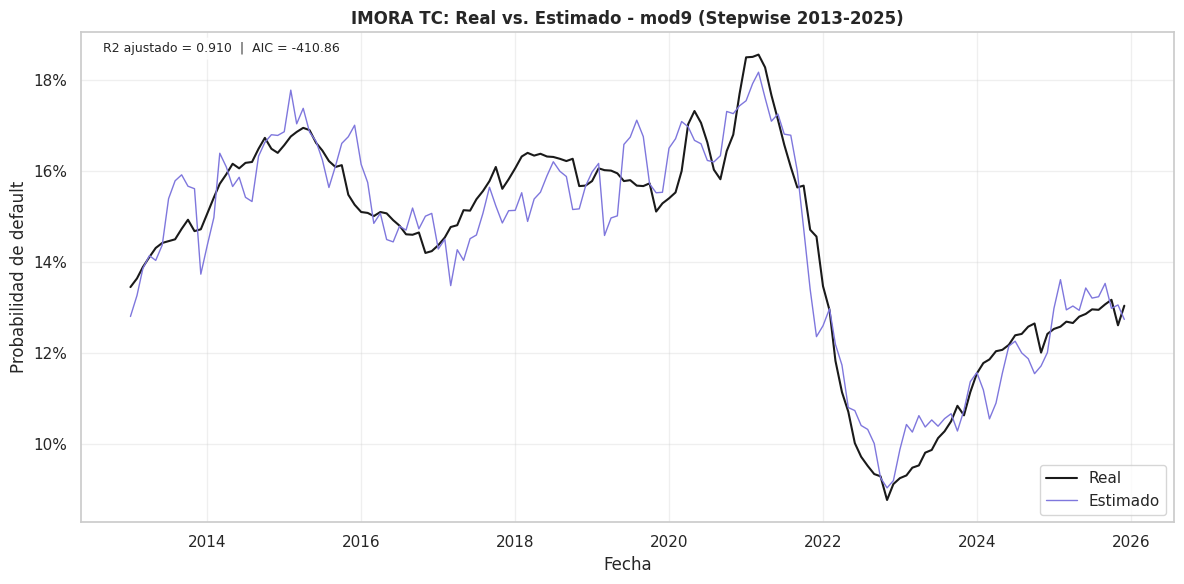

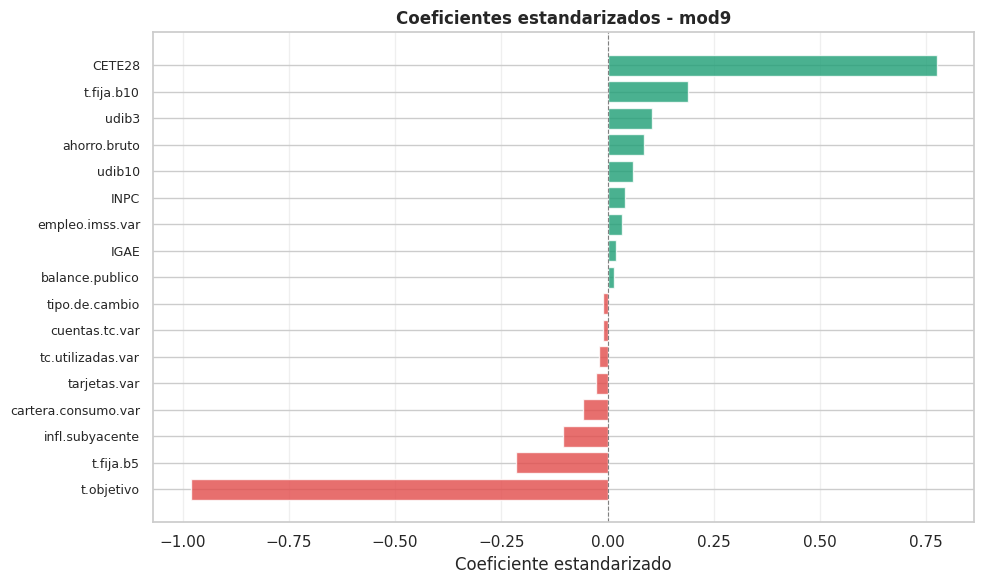

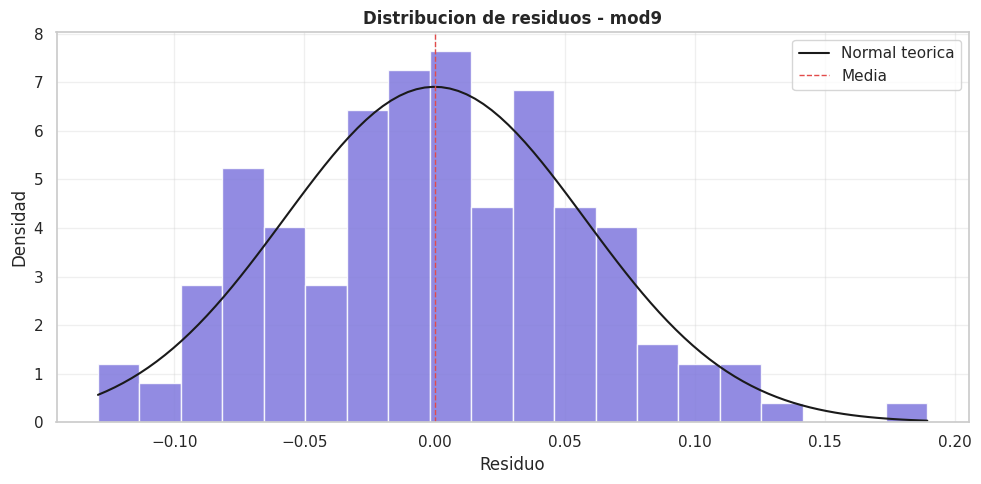

In [32]:

# ============================================================
# 13. GRAFICAS DEL MODELO GANADOR
# ============================================================

def predecir_pd(modelo, datos, vars_originales):
    """Predice PD a partir del modelo entrenado"""
    vars_modelo = modelo.model.exog_names[1:]
    X_pred = pd.DataFrame(index=datos.index)
    X_pred['const'] = 1

    for var in vars_modelo:
        if var in datos.columns:
            X_pred[var] = datos[var].values
        else:
            X_pred[var] = 0

    score_pred = modelo.predict(X_pred)
    return 1 / (1 + np.exp(-score_pred))

# Identificar dataset del modelo ganador
if ganador['Ventana'] == '2008-2025':
    datos_ganador = datasets_std['desde_2008']
    fechas_ganador = datos_ganador['Fecha'].values
elif ganador['Ventana'] == '2009-2025':
    datos_ganador = datasets_std['desde_2009']
    fechas_ganador = datos_ganador['Fecha'].values
elif ganador['Ventana'] == '2013-2025':
    datos_ganador = datasets_std['desde_2013']
    fechas_ganador = datos_ganador['Fecha'].values
else:
    datos_ganador = datasets_std['desde_2018']
    fechas_ganador = datos_ganador['Fecha'].values

if modelo_ganador is not None and len(modelo_ganador.params) > 1:
    pd_real = datos_ganador['PD'].values
    pd_estimado = predecir_pd(modelo_ganador, datos_ganador, vars_macro)

    # Grafica Real vs Estimado
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(fechas_ganador, pd_real, color='#1a1a1a', linewidth=1.5, label='Real')
    ax.plot(fechas_ganador, pd_estimado, color='#7F77DD', linewidth=1, label='Estimado')
    ax.set_title(f'IMORA TC: Real vs. Estimado - {ganador["Modelo"]} ({ganador["Tipo"]} {ganador["Ventana"]})',
                fontsize=12, fontweight='bold')
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Probabilidad de default')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x*100:.0f}%'))
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    info_text = f'R2 ajustado = {modelo_ganador.rsquared_adj:.3f}  |  AIC = {modelo_ganador.aic:.2f}'
    ax.text(0.02, 0.98, info_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    plt.tight_layout()
    plt.show()

    # Coeficientes del modelo ganador
    if len(modelo_ganador.params) > 1:
        fig, ax = plt.subplots(figsize=(10, max(6, len(modelo_ganador.params)*0.3)))
        coefs = modelo_ganador.params[1:].sort_values()
        colors_bar = ['#1D9E75' if x > 0 else '#E24B4A' for x in coefs.values]

        ax.barh(range(len(coefs)), coefs.values, color=colors_bar, alpha=0.8)
        ax.set_yticks(range(len(coefs)))
        ax.set_yticklabels(coefs.index, fontsize=9)
        ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
        ax.set_title(f'Coeficientes estandarizados - {ganador["Modelo"]}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Coeficiente estandarizado')
        ax.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()

    # Histograma de residuos
    residuos = modelo_ganador.resid
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(residuos, bins=20, density=True, color='#7F77DD', edgecolor='white', alpha=0.85)

    media_res = np.mean(residuos)
    sd_res = np.std(residuos)
    x_norm = np.linspace(min(residuos), max(residuos), 100)
    y_norm = norm.pdf(x_norm, media_res, sd_res)
    ax.plot(x_norm, y_norm, color='#1a1a1a', linewidth=1.5, label='Normal teorica')
    ax.axvline(x=media_res, color='#E24B4A', linestyle='--', linewidth=1, label='Media')
    ax.set_title(f'Distribucion de residuos - {ganador["Modelo"]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Residuo')
    ax.set_ylabel('Densidad')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
